# Матрица корреляций в Python

**Дисциплина:** Введение в анализ больших данных

Темы:
- проверка нормальности (Shapiro–Wilk);
- ранговая корреляция Спирмена;
- матрица корреляций и heatmap;
- значимость коэффициентов;
- корреляции **по группам**.

Демо-данные — датасет **tips** (чаевые). Примеры **не совпадают** с лабораторным заданием: цель — освоить методы, задание выполните самостоятельно на своих данных.


## 0. Импорт и данные


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

df = pd.read_csv("NMES1988.csv", usecols=['visits', 'health', 'chronic', 'adl', 'region',
        'age', 'gender', 'married', 'school', 'income',
        'employed', 'insurance'])




print("Размерность:", df.shape)
df.head()


Размерность: (4406, 12)


,visits,health,chronic,adl,region,age,gender,married,school,income,employed,insurance
0,5,average,2,normal,other,6.9,male,yes,6,2.8810,yes,yes
1,1,average,2,normal,other,7.4,female,yes,10,2.7478,no,yes
2,13,poor,4,limited,other,6.6,female,no,10,0.6532,no,no
3,16,poor,2,limited,other,7.6,male,yes,3,0.6588,no,yes
4,3,average,2,limited,other,7.9,female,yes,6,0.6588,no,yes


In [3]:
quant_cols = ['visits', 'chronic', 'age', 'school', 'income']
print(df[quant_cols].describe().round(2))


        visits  chronic      age   school   income
count  4406.00  4406.00  4406.00  4406.00  4406.00
mean      5.77     1.54     7.40    10.29     2.53
std       6.76     1.35     0.63     3.74     2.92
min       0.00     0.00     6.60     0.00    -1.01
25%       1.00     1.00     6.90     8.00     0.91
50%       4.00     1.00     7.30    11.00     1.70
75%       8.00     2.00     7.80    12.00     3.17
max      89.00     8.00    10.90    18.00    54.84


---
## 1. Проверка нормальности: Shapiro–Wilk

H0: выборка из нормального распределения.  
`stats.shapiro(x)` → (W, p-value).

При p > 0.05 обычно **не отвергают** H0.  
При больших n тест часто «ловит» даже мелкие отклонения — смотрите также гистограмму.


In [4]:
print("=== Shapiro–Wilk ===")
for col in quant_cols:
    x = df[col].dropna()
    W, p = stats.shapiro(x)
    print(f"{col:12s}: W={W:.4f}, p={p:.4g}")


=== Shapiro–Wilk ===
visits      : W=0.7259, p=5.713e-65
chronic     : W=0.8762, p=1.58e-50
age         : W=0.9307, p=3.602e-41
school      : W=0.9595, p=2.178e-33
income      : W=0.6050, p=3.126e-72


Если переменные не нормальны, для связи часто берут **Спирмена** (ранги), а не Пирсона.


---
## 2. Корреляция Спирмена для пары переменных

`stats.spearmanr(x, y)` → (rho, p-value).


In [12]:
rho, p = stats.spearmanr(df["visits"], df["age"])
print(f"Spearman: visits ~ age")
print(f"  коэф. корреляции (rho) = {rho:.4f}")
print(f"  p                      = {p:.4g}")


Spearman: visits ~ age
  коэф. корреляции (rho) = 0.0534
  p                      = 0.0003904


---
## 3. Матрица корреляций и heatmap

`df.corr(method="spearman")` + `sns.heatmap`.


         visits  chronic    age  school  income
visits    1.000    0.338  0.053   0.076   0.002
chronic   0.338    1.000  0.114  -0.058  -0.090
age       0.053    0.114  1.000  -0.134  -0.147
school    0.076   -0.058 -0.134   1.000   0.345
income    0.002   -0.090 -0.147   0.345   1.000


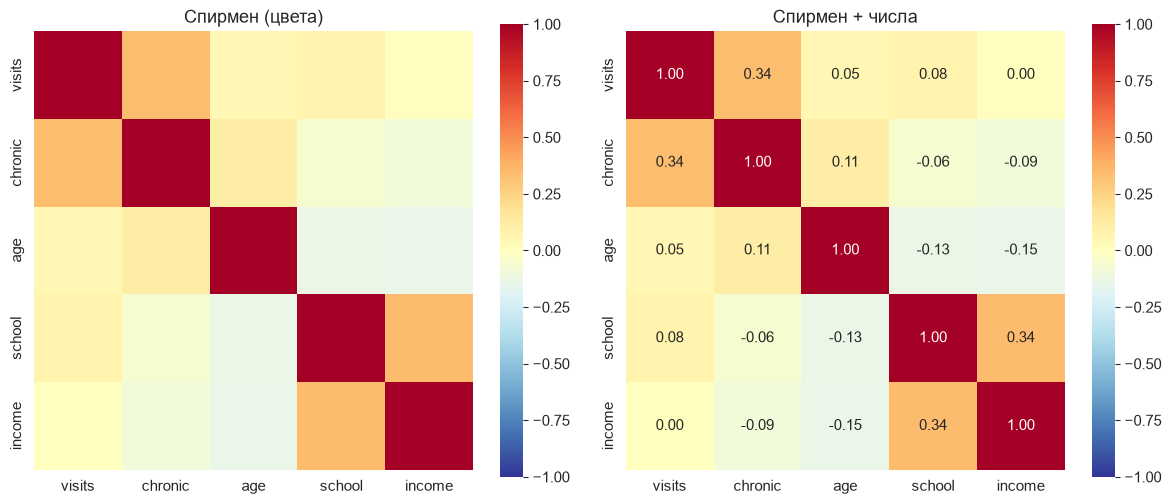

In [13]:
corr = df[quant_cols].corr(method="spearman")
print(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(corr, annot=False, cmap="RdYlBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title("Спирмен (цвета)")

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title("Спирмен + числа")
plt.tight_layout()
plt.show()


---
## 4. Значимость всех пар

Для каждой пары столбцов можно получить p-value через `spearmanr`.


In [17]:
_, pvals_matrix = stats.spearmanr(df[quant_cols])
pvals = pd.DataFrame(pvals_matrix, index=quant_cols, columns=quant_cols)

In [19]:
print("Пары с |r| < 0.8 (пример порога):\n")
for i, c1 in enumerate(quant_cols):
    for c2 in quant_cols[i+1:]:
        r = corr.loc[c1, c2]
        p = pvals.loc[c1, c2]
        if abs(r) < 0.8:
            sig = "значима" if p < 0.05 else "не значима"
            print(f"  {c1} – {c2}: r={r:.3f}, p={p:.4g} → {sig}")


Пары с |r| < 0.8 (пример порога):

  visits – chronic: r=0.338, p=7.341e-118 → значима
  visits – age: r=0.053, p=0.0003904 → значима
  visits – school: r=0.076, p=4.571e-07 → значима
  visits – income: r=0.002, p=0.8877 → не значима
  chronic – age: r=0.114, p=3.36e-14 → значима
  chronic – school: r=-0.058, p=0.0001277 → значима
  chronic – income: r=-0.090, p=1.85e-09 → значима
  age – school: r=-0.134, p=3.31e-19 → значима
  age – income: r=-0.147, p=1.178e-22 → значима
  school – income: r=0.345, p=3.118e-123 → значима


---
## 5. Корреляции **по группам** (например, по полу)


In [20]:
for g in df["gender"].dropna().unique():
    sub = df.loc[df["gender"] == g, quant_cols]
    c = sub.corr(method="spearman")
    print(f"\n=== gender = {g} (n={len(sub)}) ===")
    print(c.round(3))



=== gender = male (n=1778) ===
         visits  chronic    age  school  income
visits    1.000    0.334  0.064   0.133   0.100
chronic   0.334    1.000  0.111  -0.045  -0.054
age       0.064    0.111  1.000  -0.118  -0.141
school    0.133   -0.045 -0.118   1.000   0.405
income    0.100   -0.054 -0.141   0.405   1.000

=== gender = female (n=2628) ===
         visits  chronic    age  school  income
visits    1.000    0.340  0.040   0.037  -0.037
chronic   0.340    1.000  0.115  -0.068  -0.114
age       0.040    0.115  1.000  -0.146  -0.142
school    0.037   -0.068 -0.146   1.000   0.321
income   -0.037   -0.114 -0.142   0.321   1.000


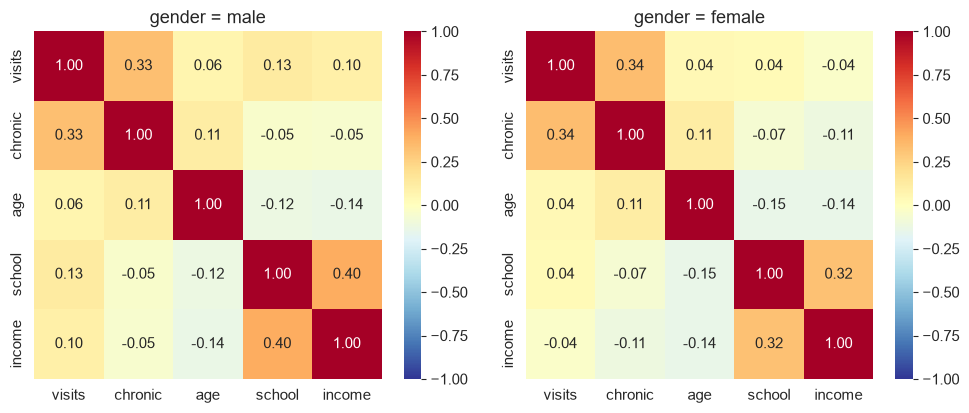

In [21]:
genders = df["gender"].dropna().unique()
fig, axes = plt.subplots(1, len(genders), figsize=(5 * len(genders), 4))
if len(genders) == 1:
    axes = [axes]
for ax, g in zip(axes, genders):
    sub = df.loc[df["gender"] == g, quant_cols]
    sns.heatmap(sub.corr(method="spearman"), annot=True, fmt=".2f",
                cmap="RdYlBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f"gender = {g}")
plt.tight_layout()
plt.show()


---
## 6. Связь одной переменной с остальными **по уровням фактора**

Пример: корреляция `tip` с `total_bill` и `size` отдельно для обеда и ужина.


In [24]:
target = 'visits'
others = ['chronic', 'age', 'school', 'income']

rows = []
# Проходим по всем уникальным регионам
for reg in df['region'].dropna().unique():
    sub = df[df['region'] == reg] # Фильтруем данные по региону
    # Для каждого показателя считаем корреляцию с visits
    for col in others:
        r, p = stats.spearmanr(sub[target], sub[col], nan_policy='omit')
        rows.append({'region': reg, 'variable': col, 'rho': r.round(4), 'p': p.round(4), 'n': len(sub)})

res_region = pd.DataFrame(rows)
print("=== Корреляция visits с другими показателями по регионам ===")
print(res_region.to_string(index=False))

=== Корреляция visits с другими показателями по регионам ===
   region variable     rho      p    n
    other  chronic  0.3586 0.0000 1614
    other      age  0.0585 0.0188 1614
    other   school  0.0522 0.0360 1614
    other   income -0.0240 0.3346 1614
  midwest  chronic  0.3343 0.0000 1157
  midwest      age  0.0069 0.8159 1157
  midwest   school  0.1239 0.0000 1157
  midwest   income  0.0408 0.1652 1157
northeast  chronic  0.3425 0.0000  837
northeast      age  0.0940 0.0065  837
northeast   school  0.0355 0.3048  837
northeast   income -0.0076 0.8269  837
     west  chronic  0.3041 0.0000  798
     west      age  0.0701 0.0477  798
     west   school  0.0618 0.0809  798
     west   income -0.0186 0.5996  798


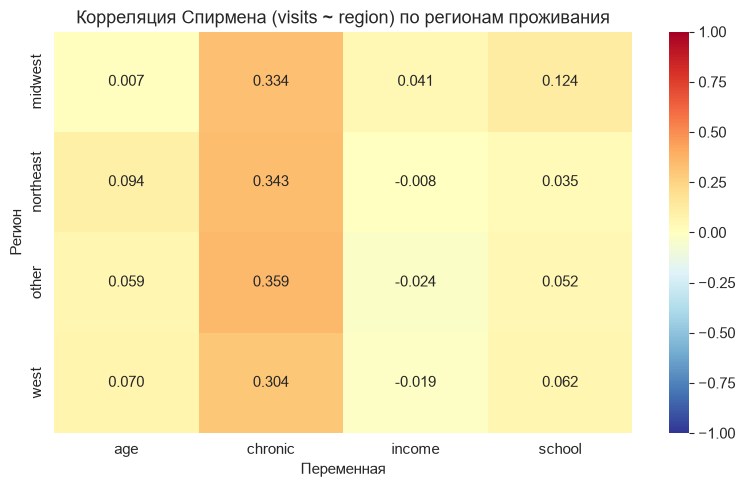

In [26]:
pivot_rho = res_region.pivot(index='region', columns='variable', values='rho')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_rho, annot=True, fmt=".3f", cmap="RdYlBu_r", center=0, vmin=-1, vmax=1)
plt.title("Корреляция Спирмена (visits ~ region) по регионам проживания")
plt.ylabel("Регион")
plt.xlabel("Переменная")
plt.tight_layout()
plt.show()


---
## Шпаргалка по методам (Python)

| Задача | Код |
|--------|-----|
| Shapiro–Wilk | `stats.shapiro(x)` → (W, p) |
| Спирмен (пара) | `stats.spearmanr(x, y)` → (rho, p) |
| Матрица Спирмена | `df.corr(method="spearman")` |
| Heatmap | `sns.heatmap(corr, annot=True, cmap="RdYlBu_r", center=0)` |
| По группам | `df.groupby("g")[cols].corr(...)` или цикл |
| p-value пар | цикл / функция с `spearmanr` |

